In [42]:
import random
import os
import numpy as np
import torch

def seed_everything(seed):
    """
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"🔒 Locked Random Seed: {seed}")



In [43]:
import torch
import numpy as np
import random

def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)

    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    return random_seed


In [44]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gc

def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

In [45]:
#load data
df_men = pd.read_csv(r"/home/ducm/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)

df_men_edit = df_men[df_men["spend"] != 29.99]

---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment      int64
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)


In [46]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel']
num_cols = ['recency', 'history_segment', 'history']
#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

# x_men_encode = pd.get_dummies(x_men, columns=cate_cols, drop_first=True)
# x_men_encode = x_men_encode.astype(float)

#train test split - stratify CHỈ bằng treatment
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify= t_men
)

# Tạo stratify cho val split - chỉ dùng treatment
stratify_var_train = pd.Series(t_men_train)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify= t_men_train
)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=True)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=True)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=True)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

# x_men = pd.DataFrame(x_men_train)
x_men_train

✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)
Train: (25567, 10), Val: (4262, 10), Test: (12784, 10)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Spend mean - Train: 1.00, Val: 0.95, Test: 1.14


array([[-1.36323828, -0.95770591, -0.65534372, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.63260109, -0.30863193, -0.31367375, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.34748118, -0.30863193, -0.4344948 , ...,  1.22273126,
         1.13764628, -0.89137716],
       ...,
       [ 0.34748118,  0.34044206,  0.30319097, ..., -0.8178412 ,
        -0.87900784,  1.12185957],
       [-1.07811837,  0.34044206,  0.16319135, ..., -0.8178412 ,
         1.13764628, -0.89137716],
       [-0.79299846, -0.95770591, -0.61911315, ..., -0.8178412 ,
        -0.87900784,  1.12185957]], shape=(25567, 10))

In [47]:
#Hillstrom-men EDITED (spend != 29.99 removed)
#split x y t
y_men_edit = df_men_edit["spend"]
t_men_edit = df_men_edit["treatment"]
x_men_edit = df_men_edit.drop(columns=["spend", "treatment", "visit", "conversion"])

#train test split - stratify by treatment
x_men_edit_train, x_men_edit_test, t_men_edit_train, t_men_edit_test, y_men_edit_train, y_men_edit_test = train_test_split(
    x_men_edit, t_men_edit.values, y_men_edit.values,
    test_size=0.3, random_state=42, stratify=t_men_edit
)

x_men_edit_train, x_men_edit_val, t_men_edit_train, t_men_edit_val, y_men_edit_train, y_men_edit_val = train_test_split(
    x_men_edit_train, t_men_edit_train, y_men_edit_train,
    test_size=(1/7), random_state=42, stratify=t_men_edit_train
)

# Encode
x_men_edit_train_encode = pd.get_dummies(x_men_edit_train, columns=cate_cols, drop_first=True)
x_men_edit_val_encode = pd.get_dummies(x_men_edit_val, columns=cate_cols, drop_first=True)
x_men_edit_test_encode = pd.get_dummies(x_men_edit_test, columns=cate_cols, drop_first=True)

# Align columns to train
x_men_edit_val_encode = x_men_edit_val_encode.reindex(columns=x_men_edit_train_encode.columns, fill_value=0)
x_men_edit_test_encode = x_men_edit_test_encode.reindex(columns=x_men_edit_train_encode.columns, fill_value=0)

# Scale
scaler_edit = StandardScaler()
x_men_edit_train_scaled = scaler_edit.fit_transform(x_men_edit_train_encode)
x_men_edit_val_scaled = scaler_edit.transform(x_men_edit_val_encode)
x_men_edit_test_scaled = scaler_edit.transform(x_men_edit_test_encode)

print("✅ EDITED Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)")
print(f"Train: {x_men_edit_train_scaled.shape}, Val: {x_men_edit_val_scaled.shape}, Test: {x_men_edit_test_scaled.shape}")
print(f"Treatment distribution - Train: {np.mean(t_men_edit_train):.2%}, Val: {np.mean(t_men_edit_val):.2%}, Test: {np.mean(t_men_edit_test):.2%}")
print(f"Spend mean - Train: {np.mean(y_men_edit_train):.2f}, Val: {np.mean(y_men_edit_val):.2f}, Test: {np.mean(y_men_edit_test):.2f}")

✅ EDITED Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)
Train: (25509, 10), Val: (4252, 10), Test: (12756, 10)
Treatment distribution - Train: 49.95%, Val: 49.95%, Test: 49.95%
Spend mean - Train: 1.01, Val: 0.48, Test: 1.06


In [48]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)
batch_size = 800
#Transform EDITED data to tensor
x_men_edit_train_t = to_tensor(x_men_edit_train_scaled)
x_men_edit_val_t = to_tensor(x_men_edit_val_scaled)
x_men_edit_test_t = to_tensor(x_men_edit_test_scaled)

y_men_edit_train_t = to_tensor(y_men_edit_train).unsqueeze(1)
y_men_edit_val_t = to_tensor(y_men_edit_val).unsqueeze(1)
y_men_edit_test_t = to_tensor(y_men_edit_test).unsqueeze(1)

t_men_edit_train_t = to_tensor(t_men_edit_train.astype(float)).unsqueeze(1)
t_men_edit_val_t = to_tensor(t_men_edit_val.astype(float)).unsqueeze(1)
t_men_edit_test_t = to_tensor(t_men_edit_test.astype(float)).unsqueeze(1)

#Data loader (edited)
train_dataset_edited = TensorDataset(x_men_edit_train_t, t_men_edit_train_t, y_men_edit_train_t)
val_dataset_edited = TensorDataset(x_men_edit_val_t, t_men_edit_val_t, y_men_edit_val_t)
test_dataset_edited = TensorDataset(x_men_edit_test_t, t_men_edit_test_t, y_men_edit_test_t)

train_loader_edited = DataLoader(train_dataset_edited, batch_size=batch_size, shuffle=True)
val_loader_edited = DataLoader(val_dataset_edited, batch_size=batch_size, shuffle=False)
test_loader_edited = DataLoader(test_dataset_edited, batch_size=batch_size, shuffle=False)

print("-------------------------------------------------------------")
print("✅Completed transform EDITED data to tensor✅")
print(f"Shape of train: x={x_men_edit_train_t.shape}; y={y_men_edit_train_t.shape}; t={t_men_edit_train_t.shape}")
print(f"Shape of val: x={x_men_edit_val_t.shape}; y={y_men_edit_val_t.shape}; t={t_men_edit_val_t.shape}")
print(f"Shape of test: x={x_men_edit_test_t.shape}; y={y_men_edit_test_t.shape}; t={t_men_edit_test_t.shape}")

-------------------------------------------------------------
✅Completed transform EDITED data to tensor✅
Shape of train: x=torch.Size([25509, 10]); y=torch.Size([25509, 1]); t=torch.Size([25509, 1])
Shape of val: x=torch.Size([4252, 10]); y=torch.Size([4252, 1]); t=torch.Size([4252, 1])
Shape of test: x=torch.Size([12756, 10]); y=torch.Size([12756, 1]); t=torch.Size([12756, 1])


In [49]:
x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 10]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [50]:
from metrics import auuc, auqc, lift, krcc

In [51]:
from dragonnet import Dragonnet

In [52]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0015, std=14.5993
Y train zeros: 25338 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [55]:
epochs = 150
alpha = 1 
beta = 1
lr = 1e-4
wd = 1e-4
early_stop_metric = "qini"
ema = True
ema_alpha = 0.05
patience = 30
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 50

print (f" epochs = {epochs}")
print (f" alpha = {alpha}")
print (f" beta = {beta}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")

 epochs = 150
 alpha = 1
 beta = 1
 learning rate = 0.0001
 weight decay = 0.0001
 early stop = qini
 use ema = True
 ema alpha = 0.05
 patience = 30
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 51
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/150 | Base Loss: 19.0084 | Tarreg Loss: 20.223431 | Total Loss: 39.2319 | Val Loss: 40.0341 | Raw Qini: 0.3692 | EMA Trend: 0.3692 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 32.6672 | Tarreg Loss: 279.328583 | Total Loss: 311.9958 | Val Loss: 28.1191 | Raw Qini: -0.3964 | EMA Trend: 0.3309 | (patience: 1/30)
Epoch 3/150 | Base Loss: 17.9902 | Tarreg Loss: 264.358826 | Total Loss: 282.3490 | Val Loss: 17.9750 | Raw Qini: -0.6758 | EMA Trend: 0.2806 | (patience: 2/30)
Epoch 4/150 | Base Loss: 11.9278 | Tarreg Loss: 569.703003 | Total Loss: 581.6308 | Val Loss: 16.0825 | Raw Qini: -0.2256 | EMA Trend: 0.2553 | (patience: 3/30)
Epoch 5/150 | Base Loss: 17.0269 | Tarreg Loss: 88.425133 | Total Loss: 105.4520 | Val Loss: 15.2933 | Raw Qini: -0.0500 | EMA Trend: 0.2400 | (patience: 4/30)
Epoch 6/150 | Base Loss: 7.3238 | Tarreg Loss: 15.047903 | Total Loss: 22.3717 | Val Loss: 14.2023 | Raw Qini: -0.0769 | EMA Trend: 0.2241 | (patience: 5/30)
Epoch 7/150 | Base Loss: 15.6095

/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


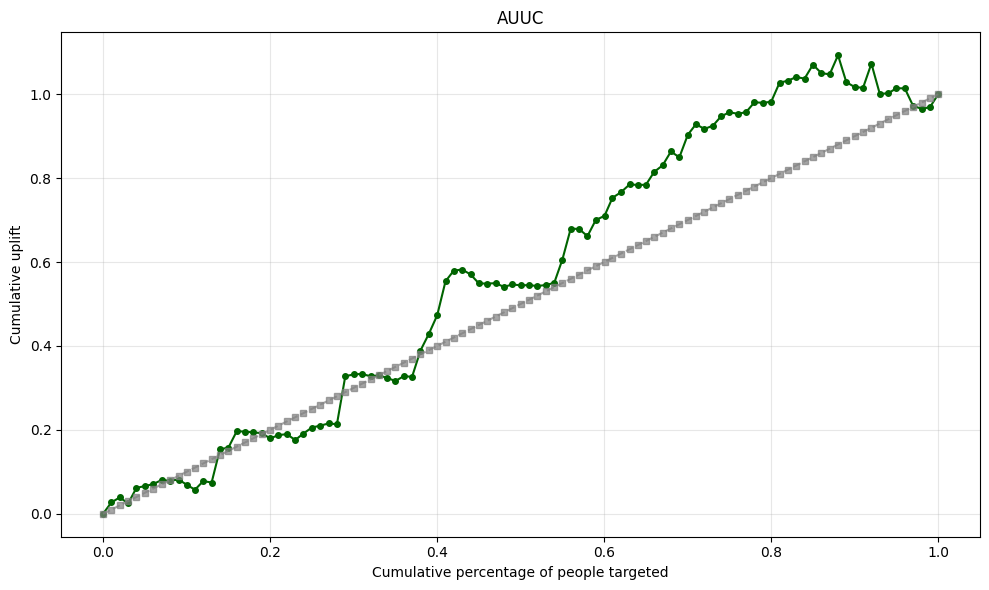

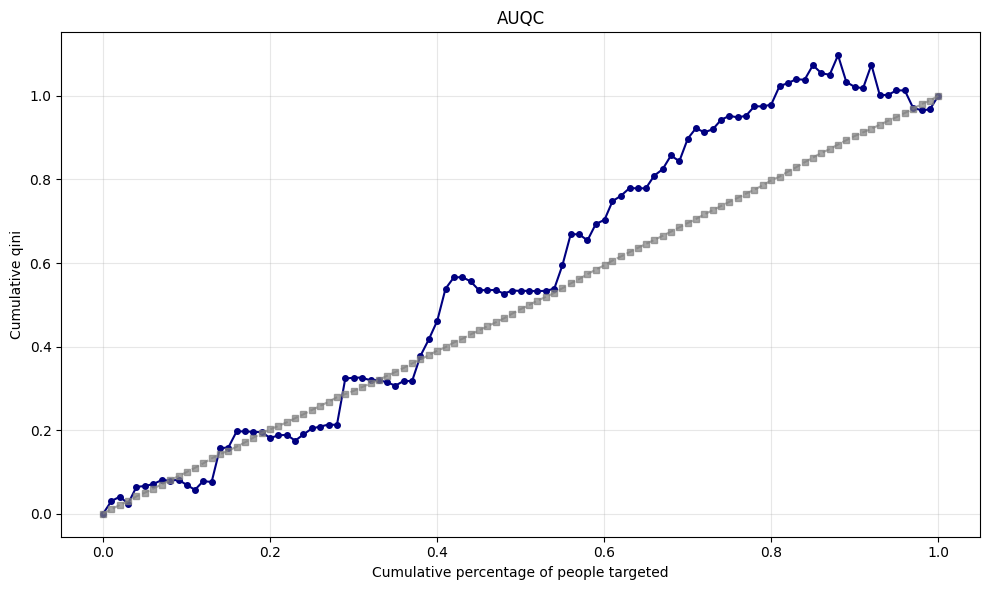

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.573
AUQC: 0.569
Lift: 1.137
KRCC: 0.017
Evaluating on EDITED test set 🔃🔃🔃


/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


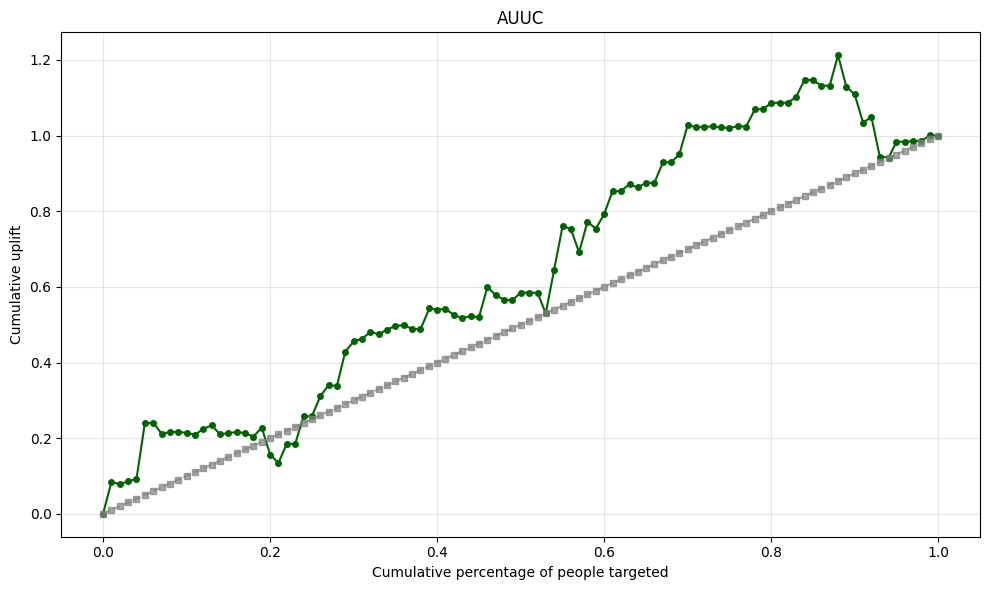

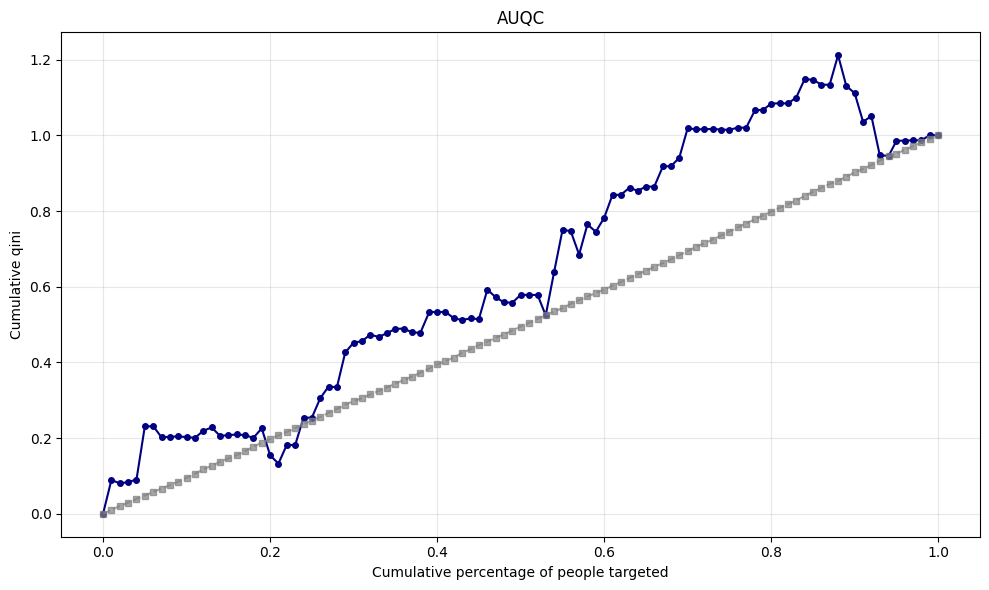

----------------------------------------
[EDITED TEST SET]
AUUC: 0.641
AUQC: 0.636
Lift: 1.085
KRCC: 0.031
seed: 412312


In [56]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

# === Evaluate on EDITED test set ===
print("=" * 50)
print("Evaluating on EDITED test set 🔃🔃🔃")
x_men_edit_test_t_on_device = x_men_edit_test_t.to(device)
y0_pred_e, y1_pred_e, _, _ = dragonnet.predict(x_men_edit_test_t_on_device)
uplift_pred_e = (y1_pred_e - y0_pred_e).cpu().numpy().flatten()
y_true_e = y_men_edit_test_t.cpu().numpy().flatten()
t_true_e = t_men_edit_test_t.cpu().numpy().flatten()

auuc_score_e = auuc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
auqc_score_e = auqc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
lift_score_e = lift(y_true_e, t_true_e, uplift_pred_e, h=0.3)
krcc_score_e = krcc(y_true_e, t_true_e, uplift_pred_e, bins=100)

print("-" * 40)
print("[EDITED TEST SET]")
print(f"AUUC: {auuc_score_e:.3f}")
print(f"AUQC: {auqc_score_e:.3f}")
print(f"Lift: {lift_score_e:.3f}")
print(f"KRCC: {krcc_score_e:.3f}")
print(f"seed: {seed}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 51
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Base Loss: 39.3024 | Tarreg Loss: 123.292252 | Total Loss: 162.5946 | Val Loss: 39.1891 | Raw Qini: -2.2120 | EMA Trend: -2.2120 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 26.1061 | Tarreg Loss: 85.678146 | Total Loss: 111.7842 | Val Loss: 26.9277 | Raw Qini: -1.1954 | EMA Trend: -2.1612 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Base Loss: 19.6993 | Tarreg Loss: 420.070282 | Total Loss: 439.7695 | Val Loss: 18.1561 | Raw Qini: -2.0933 | EMA Trend: -2.1578 | ✓ above trend but not peak (patience: 1/30)


Epoch 4/150 | Base Loss: 14.5339 | Tarreg Loss: 148.424042 | Total Loss: 162.9579 | Val Loss: 15.4783 | Raw Qini: -0.2616 | EMA Trend: -2.0630 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/150 | Base Loss: 15.0113 | Tarreg Loss: 73.384888 | Total Loss: 88.3962 | Val Loss: 14.1610 | Raw Qini: 0.8920 | EMA Trend: -1.9152 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/150 | Base Loss: 14.3386 | Tarreg Loss: 259.580933 | Total Loss: 273.9196 | Val Loss: 13.3012 | Raw Qini: 0.8620 | EMA Trend: -1.7764 | ✓ above trend but not peak (patience: 1/30)
Epoch 7/150 | Base Loss: 13.9354 | Tarreg Loss: 345.961212 | Total Loss: 359.8967 | Val Loss: 12.6980 | Raw Qini: 1.2118 | EMA Trend: -1.6269 | ⭐ NEW BEST (peak ≥ trend)
Epoch 8/150 | Base Loss: 6.8331 | Tarreg Loss: 103.467278 | Total Loss: 110.3004 | Val Loss: 12.3885 | Raw Qini: 0.6870 | EMA Trend: -1.5113 | ✓ above trend but not peak (patience: 1/30)
Epoch 9/150 | Base Loss: 14.0024 | Tarreg Loss: 475.399017 | Total Loss: 489.4014 | Val Loss: 11.7709 | Raw Qini: 0.

/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


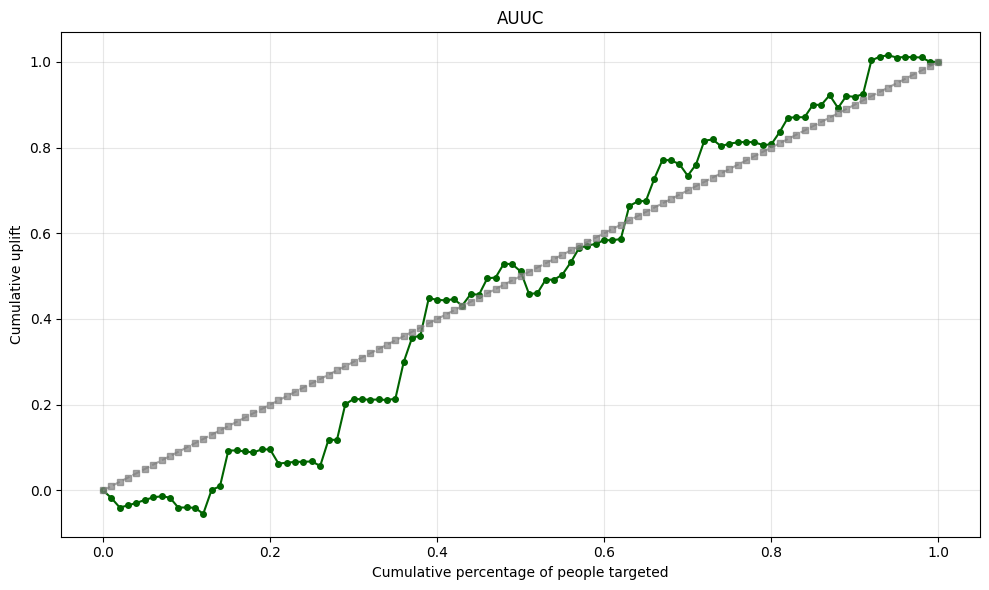

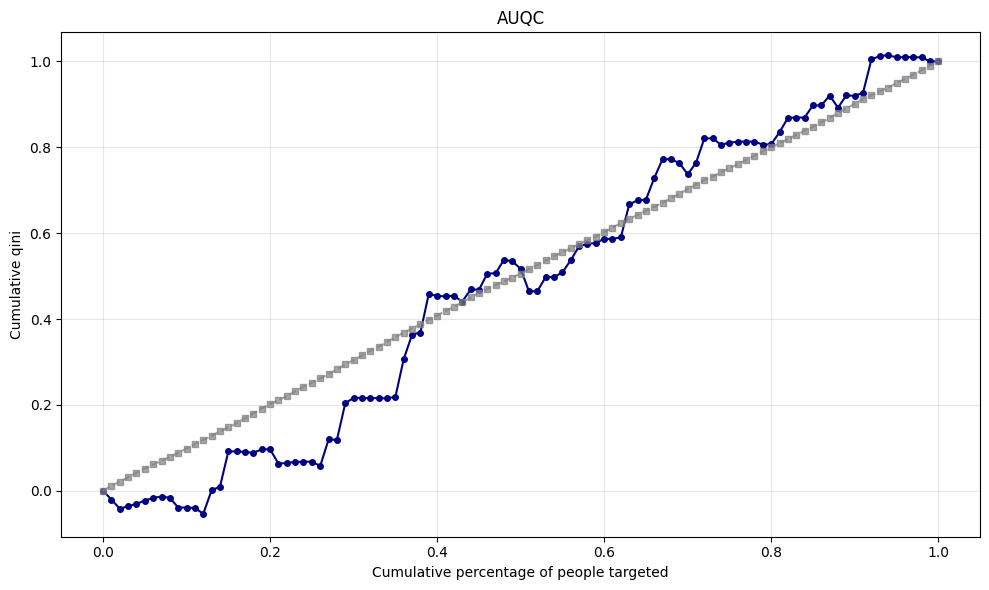

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.476
AUQC: 0.479
Lift: 0.729
KRCC: -0.047
Evaluating on EDITED test set 🔃🔃🔃


/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


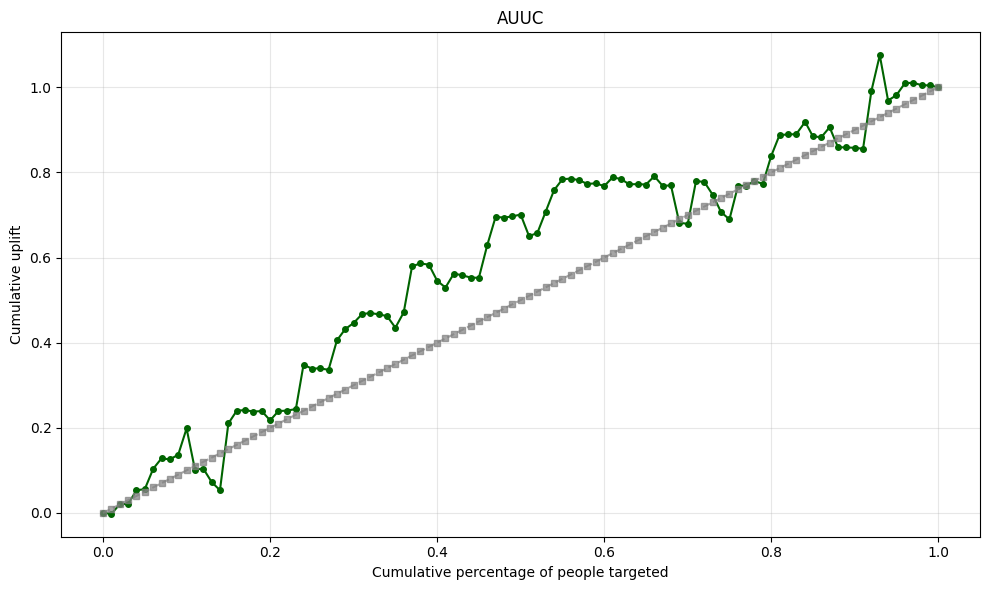

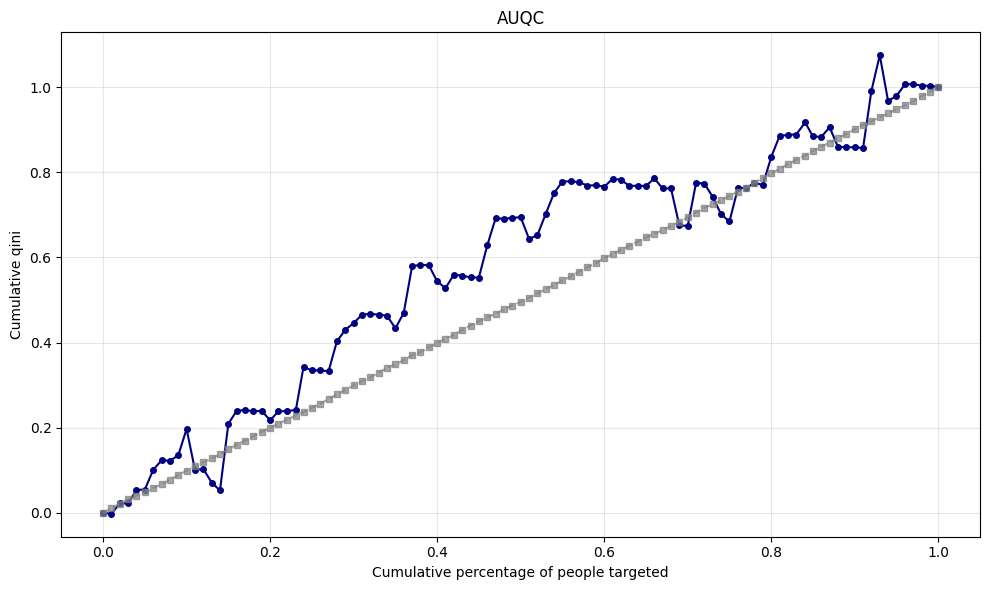

----------------------------------------
[EDITED TEST SET]
AUUC: 0.580
AUQC: 0.578
Lift: 1.062
KRCC: 0.056
seed: 42


In [57]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

# === Evaluate on EDITED test set ===
print("=" * 50)
print("Evaluating on EDITED test set 🔃🔃🔃")
x_men_edit_test_t_on_device = x_men_edit_test_t.to(device)
y0_pred_e, y1_pred_e, _, _ = dragonnet.predict(x_men_edit_test_t_on_device)
uplift_pred_e = (y1_pred_e - y0_pred_e).cpu().numpy().flatten()
y_true_e = y_men_edit_test_t.cpu().numpy().flatten()
t_true_e = t_men_edit_test_t.cpu().numpy().flatten()

auuc_score_e = auuc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
auqc_score_e = auqc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
lift_score_e = lift(y_true_e, t_true_e, uplift_pred_e, h=0.3)
krcc_score_e = krcc(y_true_e, t_true_e, uplift_pred_e, bins=100)

print("-" * 40)
print("[EDITED TEST SET]")
print(f"AUUC: {auuc_score_e:.3f}")
print(f"AUQC: {auqc_score_e:.3f}")
print(f"Lift: {lift_score_e:.3f}")
print(f"KRCC: {krcc_score_e:.3f}")
print(f"seed: {seed}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 51
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/150 | Base Loss: 46.8427 | Tarreg Loss: 289.839966 | Total Loss: 336.6827 | Val Loss: 41.9125 | Raw Qini: -0.1149 | EMA Trend: -0.1149 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 39.5150 | Tarreg Loss: 393.144989 | Total Loss: 432.6600 | Val Loss: 32.1227 | Raw Qini: 0.4412 | EMA Trend: -0.0871 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Base Loss: 20.5734 | Tarreg Loss: 392.151489 | Total Loss: 412.7249 | Val Loss: 18.4526 | Raw Qini: 0.8156 | EMA Trend: -0.0420 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Base Loss: 15.0759 | Tarreg Loss: 30.425613 | Total Loss: 45.5015 | Val Loss: 16.6004 | Raw Qini: 0.6786 | EMA Trend: -0.0060 | ✓ above trend but not peak (patience: 1/30)
Epoch 5/150 | Base Loss: 15.0951 | Tarreg Loss: 118.125893 | Total Loss: 133.2210 | Val Loss: 15.2019 | Raw Qini: 0.3071 | EMA Trend: 0.0097 | ✓ above trend but not peak (patience: 2/30)
Epoch 6/150 | Base Loss: 15.6557 | Tarreg Loss: 326.969727 | Total Loss: 342.6255 | Val Loss: 14.4247 | Raw Qini: 0.

/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


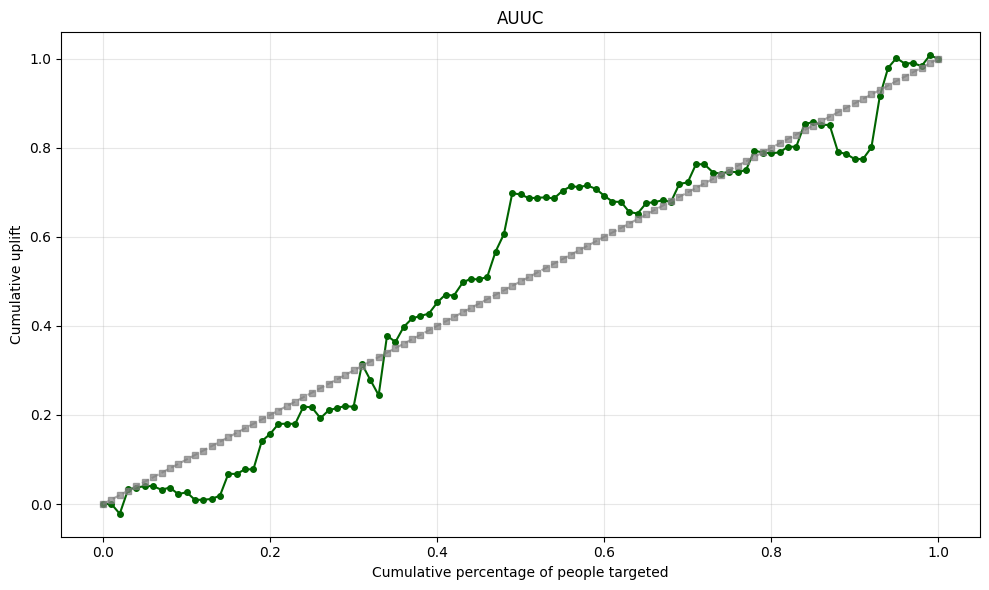

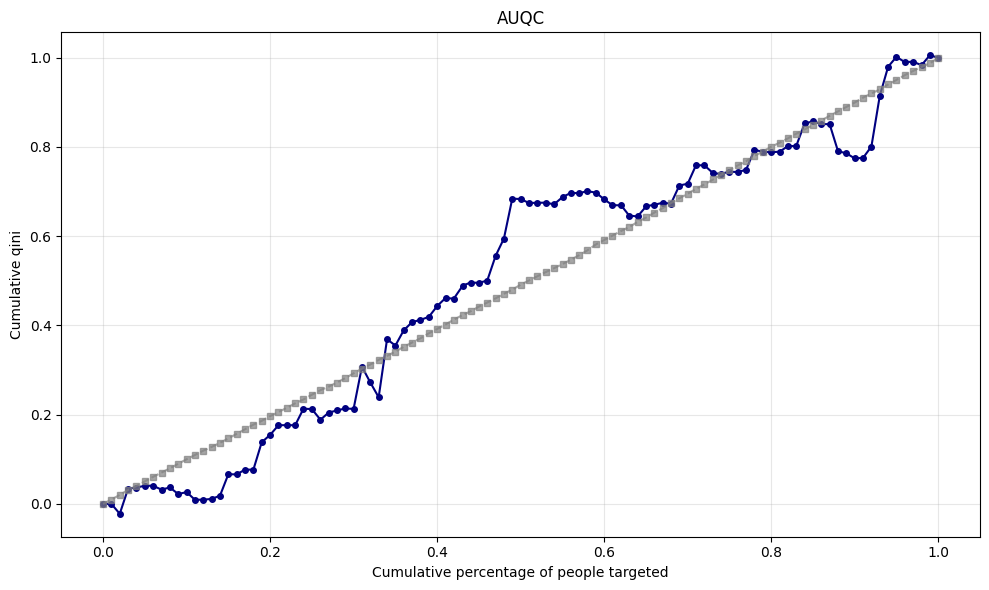

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.507
AUQC: 0.502
Lift: 0.747
KRCC: 0.043
Evaluating on EDITED test set 🔃🔃🔃


/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


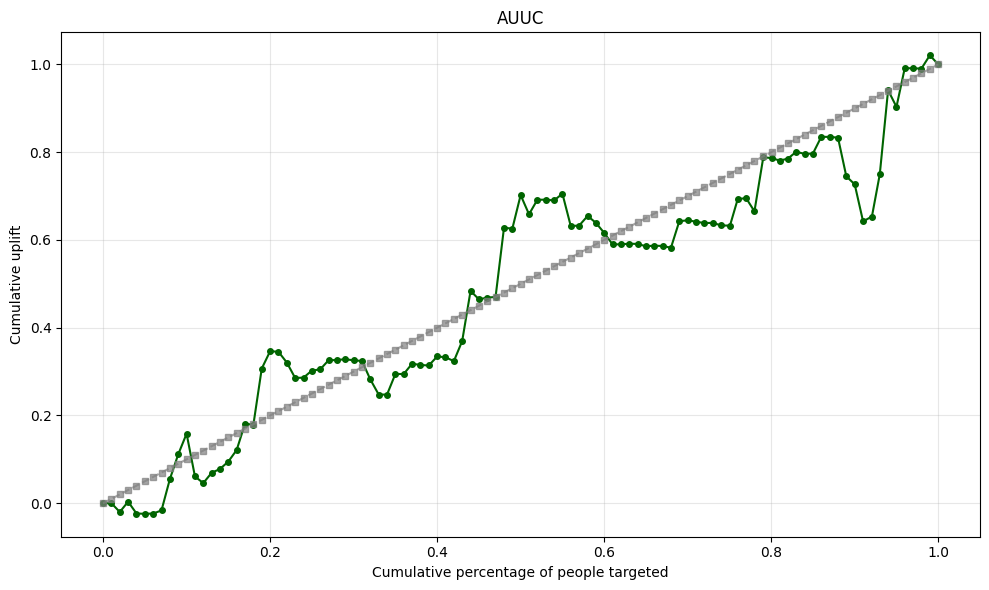

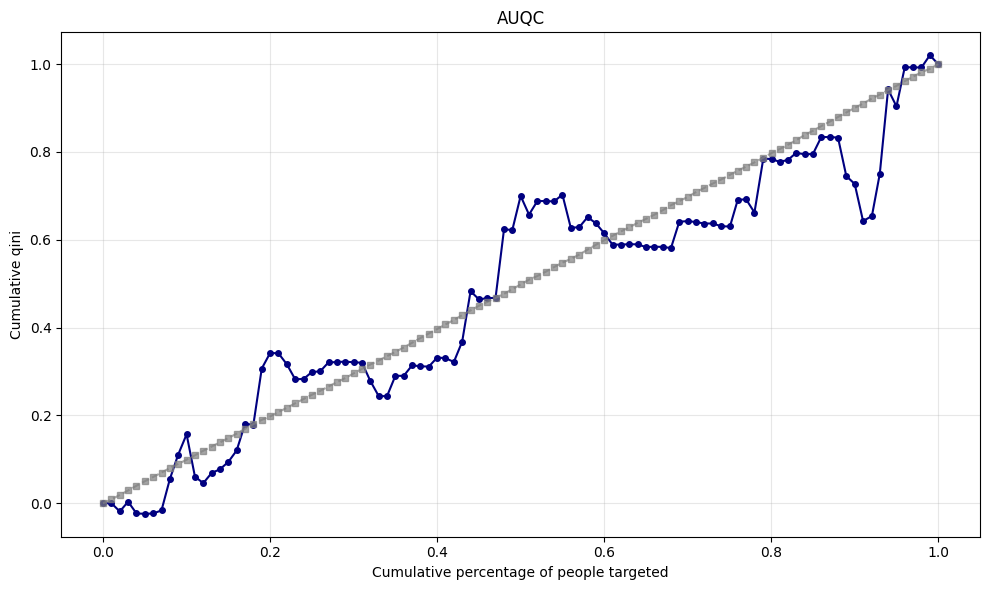

----------------------------------------
[EDITED TEST SET]
AUUC: 0.484
AUQC: 0.482
Lift: 0.775
KRCC: 0.061
seed: 1874


In [58]:
seed = 1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

# === Evaluate on EDITED test set ===
print("=" * 50)
print("Evaluating on EDITED test set 🔃🔃🔃")
x_men_edit_test_t_on_device = x_men_edit_test_t.to(device)
y0_pred_e, y1_pred_e, _, _ = dragonnet.predict(x_men_edit_test_t_on_device)
uplift_pred_e = (y1_pred_e - y0_pred_e).cpu().numpy().flatten()
y_true_e = y_men_edit_test_t.cpu().numpy().flatten()
t_true_e = t_men_edit_test_t.cpu().numpy().flatten()

auuc_score_e = auuc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
auqc_score_e = auqc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
lift_score_e = lift(y_true_e, t_true_e, uplift_pred_e, h=0.3)
krcc_score_e = krcc(y_true_e, t_true_e, uplift_pred_e, bins=100)

print("-" * 40)
print("[EDITED TEST SET]")
print(f"AUUC: {auuc_score_e:.3f}")
print(f"AUQC: {auqc_score_e:.3f}")
print(f"Lift: {lift_score_e:.3f}")
print(f"KRCC: {krcc_score_e:.3f}")
print(f"seed: {seed}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 51
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/150 | Base Loss: 24.9595 | Tarreg Loss: 138.908478 | Total Loss: 163.8680 | Val Loss: 39.0891 | Raw Qini: -0.1823 | EMA Trend: -0.1823 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 15.1806 | Tarreg Loss: 15.617775 | Total Loss: 30.7984 | Val Loss: 26.6566 | Raw Qini: -0.0084 | EMA Trend: -0.1736 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Base Loss: 18.6575 | Tarreg Loss: 371.598389 | Total Loss: 390.2558 | Val Loss: 18.0232 | Raw Qini: 0.5319 | EMA Trend: -0.1383 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Base Loss: 18.7574 | Tarreg Loss: 336.224243 | Total Loss: 354.9816 | Val Loss: 16.2440 | Raw Qini: 0.5820 | EMA Trend: -0.1023 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/150 | Base Loss: 15.1214 | Tarreg Loss: 80.547844 | Total Loss: 95.6693 | Val Loss: 15.1918 | Raw Qini: 0.6894 | EMA Trend: -0.0627 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/150 | Base Loss: 13.9401 | Tarreg Loss: 123.076706 | Total Loss: 137.0168 | Val Loss: 14.1373 | Raw Qini: 0.5818 | EMA Trend: -0.0305 | ✓ above 

/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


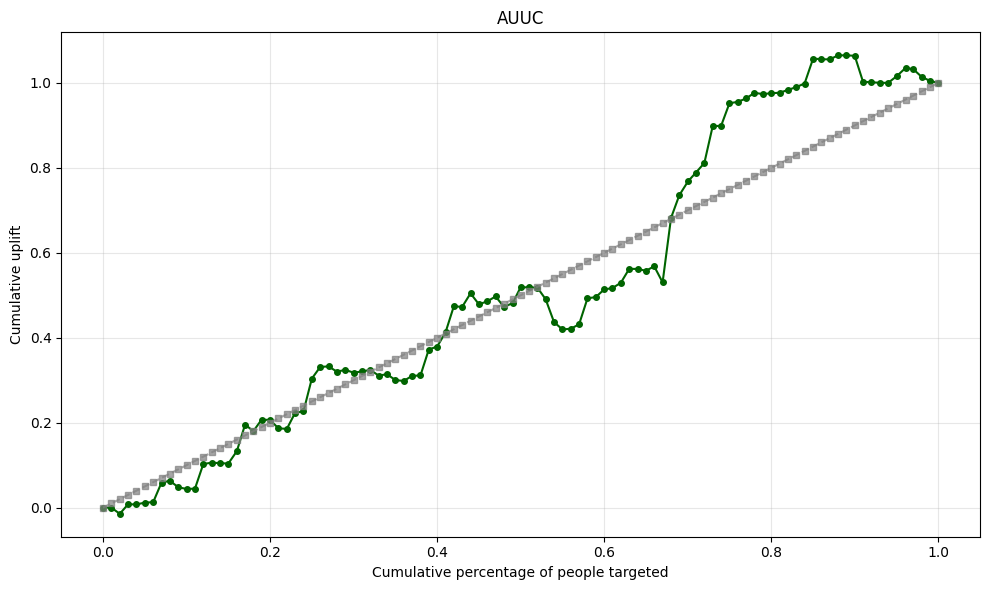

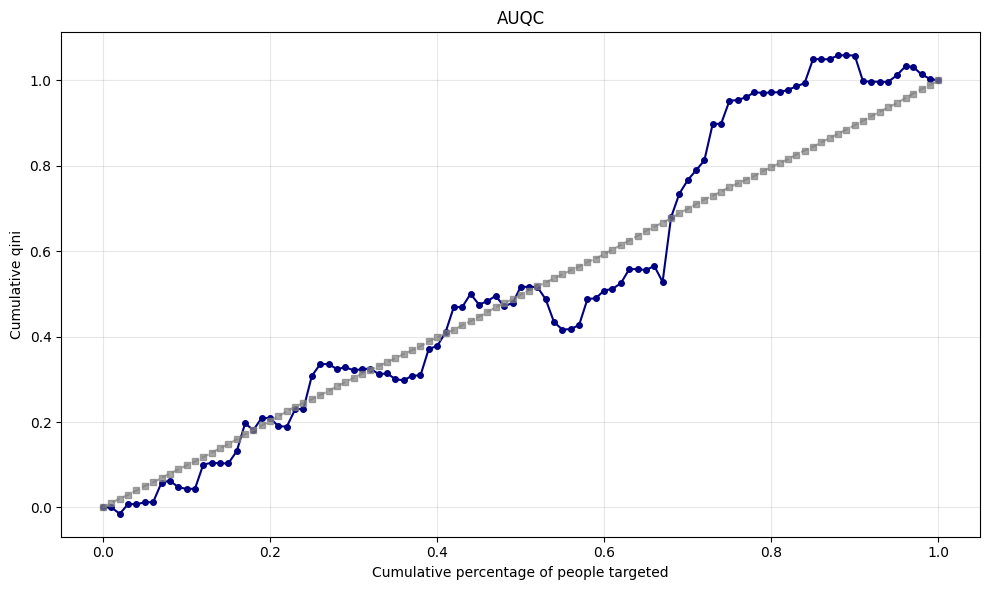

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.523
AUQC: 0.521
Lift: 1.087
KRCC: -0.006
Evaluating on EDITED test set 🔃🔃🔃


/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


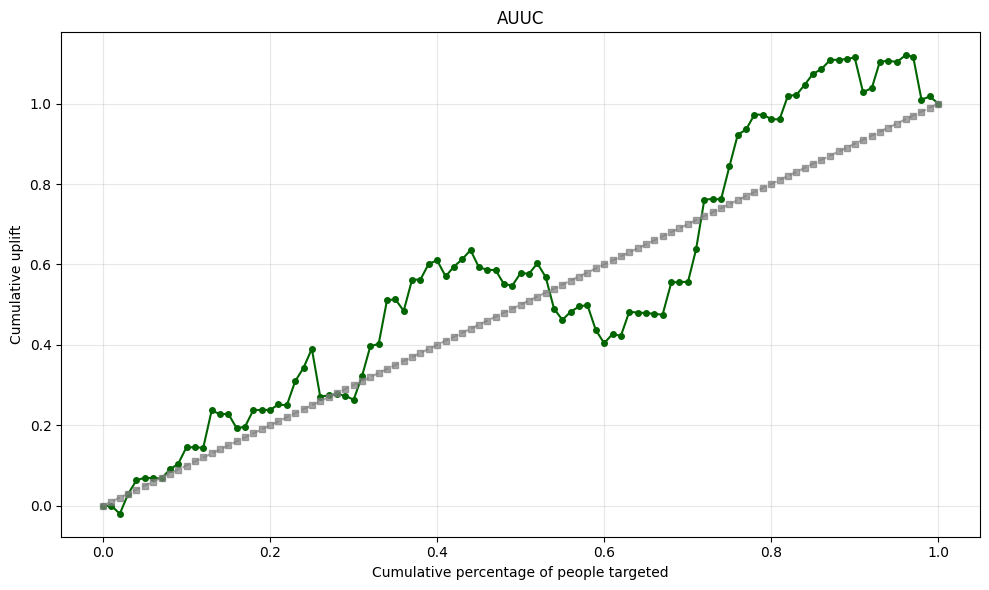

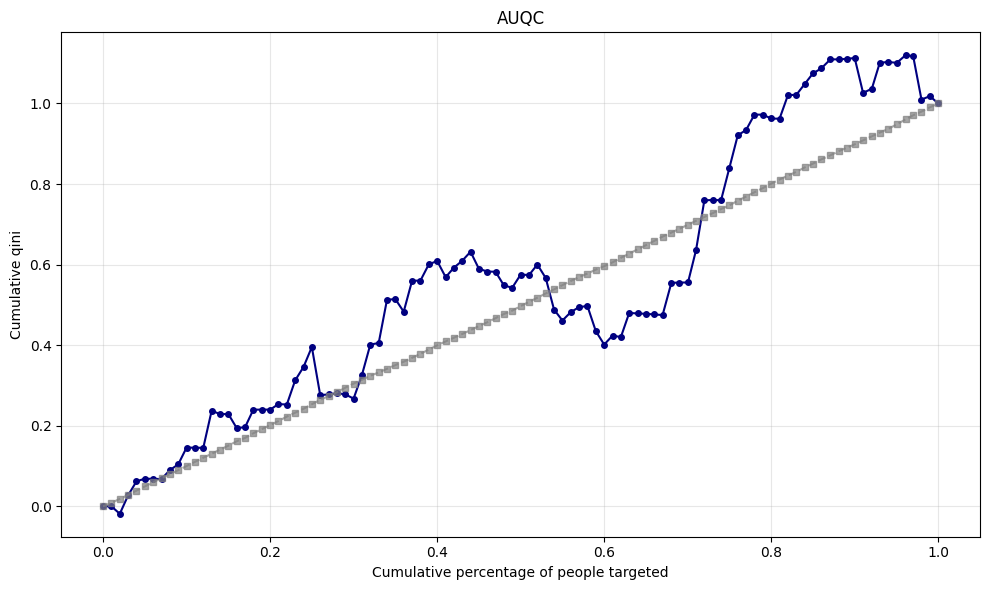

----------------------------------------
[EDITED TEST SET]
AUUC: 0.557
AUQC: 0.556
Lift: 0.627
KRCC: 0.019
seed: 902745


In [59]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

# === Evaluate on EDITED test set ===
print("=" * 50)
print("Evaluating on EDITED test set 🔃🔃🔃")
x_men_edit_test_t_on_device = x_men_edit_test_t.to(device)
y0_pred_e, y1_pred_e, _, _ = dragonnet.predict(x_men_edit_test_t_on_device)
uplift_pred_e = (y1_pred_e - y0_pred_e).cpu().numpy().flatten()
y_true_e = y_men_edit_test_t.cpu().numpy().flatten()
t_true_e = t_men_edit_test_t.cpu().numpy().flatten()

auuc_score_e = auuc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
auqc_score_e = auqc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
lift_score_e = lift(y_true_e, t_true_e, uplift_pred_e, h=0.3)
krcc_score_e = krcc(y_true_e, t_true_e, uplift_pred_e, bins=100)

print("-" * 40)
print("[EDITED TEST SET]")
print(f"AUUC: {auuc_score_e:.3f}")
print(f"AUQC: {auqc_score_e:.3f}")
print(f"Lift: {lift_score_e:.3f}")
print(f"KRCC: {krcc_score_e:.3f}")
print(f"seed: {seed}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 51
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/150 | Base Loss: 47.6738 | Tarreg Loss: 202.489136 | Total Loss: 250.1629 | Val Loss: 44.6977 | Raw Qini: 0.8098 | EMA Trend: 0.8098 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 31.0610 | Tarreg Loss: 20.464449 | Total Loss: 51.5255 | Val Loss: 30.9921 | Raw Qini: 0.3996 | EMA Trend: 0.7893 | (patience: 1/30)
Epoch 3/150 | Base Loss: 22.6044 | Tarreg Loss: 397.470032 | Total Loss: 420.0745 | Val Loss: 18.8254 | Raw Qini: -1.1781 | EMA Trend: 0.6909 | (patience: 2/30)
Epoch 4/150 | Base Loss: 15.6765 | Tarreg Loss: 41.839081 | Total Loss: 57.5156 | Val Loss: 16.3385 | Raw Qini: -1.9551 | EMA Trend: 0.5586 | (patience: 3/30)
Epoch 5/150 | Base Loss: 15.9251 | Tarreg Loss: 52.887238 | Total Loss: 68.8123 | Val Loss: 15.1435 | Raw Qini: -2.0058 | EMA Trend: 0.4304 | (patience: 4/30)
Epoch 6/150 | Base Loss: 13.3777 | Tarreg Loss: 28.902933 | Total Loss: 42.2806 | Val Loss: 13.7000 | Raw Qini: -1.7868 | EMA Trend: 0.3195 | (patience: 5/30)
Epoch 7/150 | Base Loss: 13.3419 | 

/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


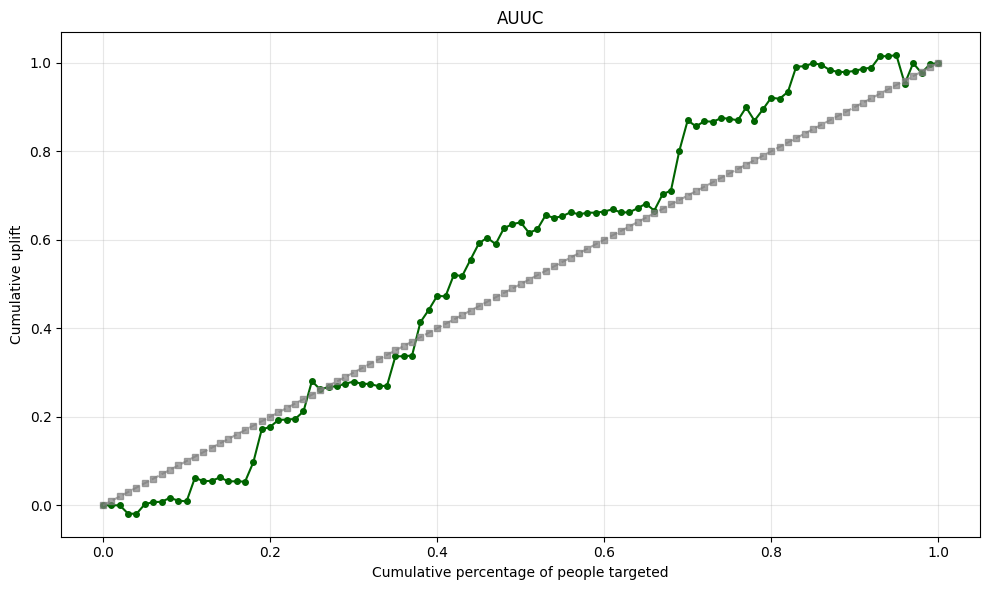

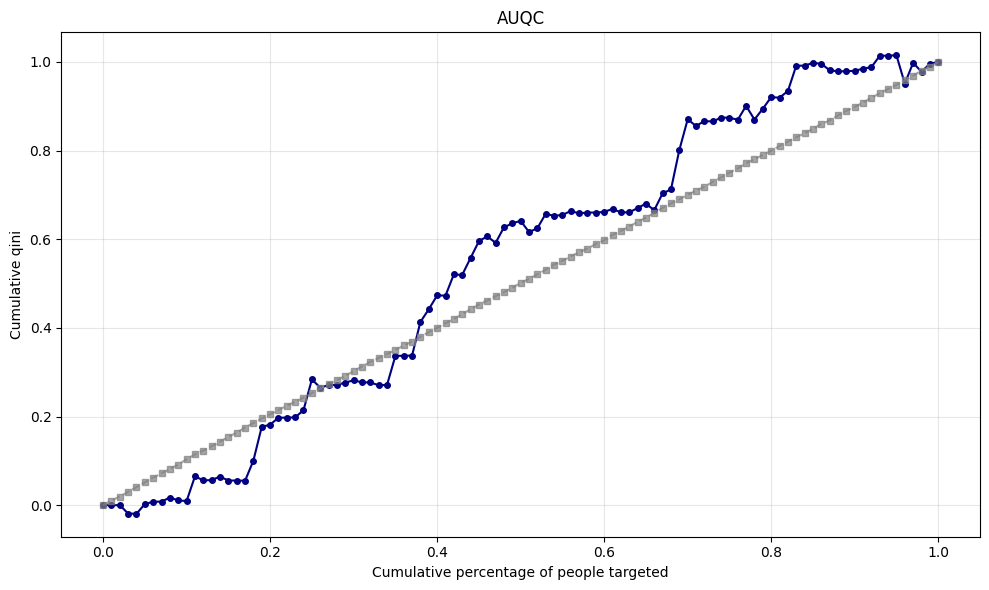

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.541
AUQC: 0.541
Lift: 0.956
KRCC: -0.001
Evaluating on EDITED test set 🔃🔃🔃


/home/ducm/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


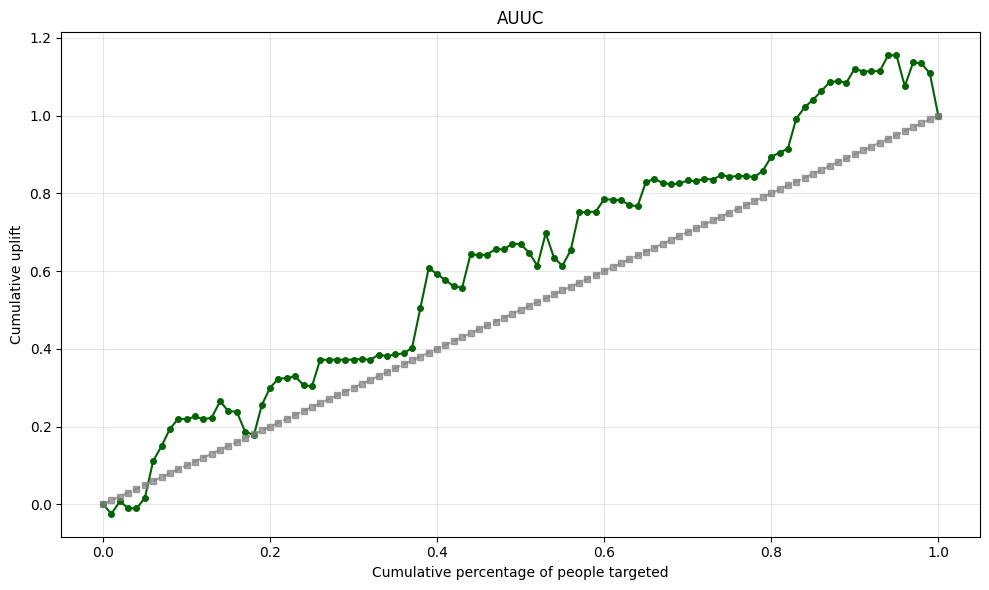

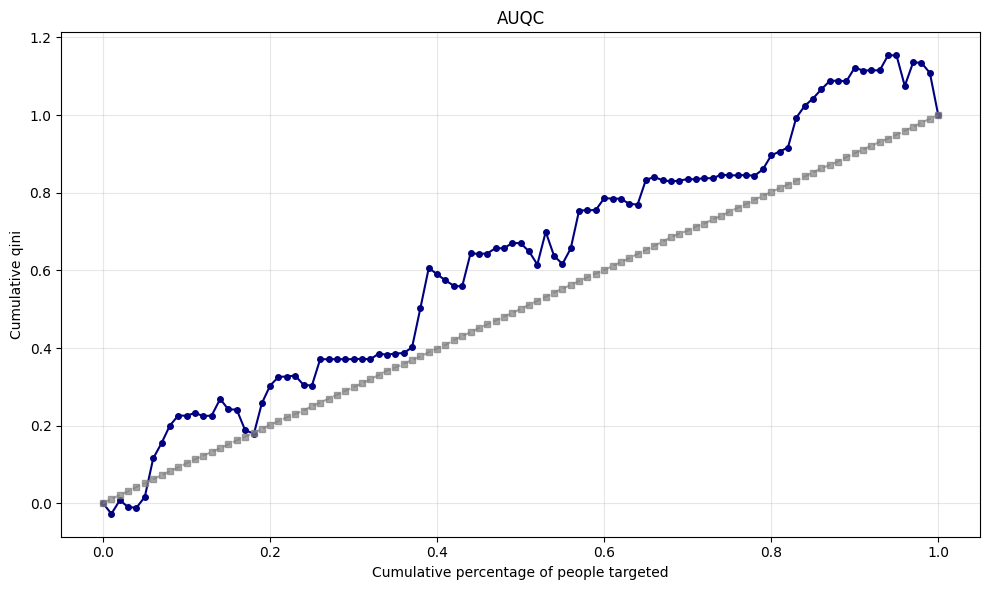

----------------------------------------
[EDITED TEST SET]
AUUC: 0.617
AUQC: 0.618
Lift: 0.886
KRCC: -0.007
seed: 1


In [60]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

# === Evaluate on EDITED test set ===
print("=" * 50)
print("Evaluating on EDITED test set 🔃🔃🔃")
x_men_edit_test_t_on_device = x_men_edit_test_t.to(device)
y0_pred_e, y1_pred_e, _, _ = dragonnet.predict(x_men_edit_test_t_on_device)
uplift_pred_e = (y1_pred_e - y0_pred_e).cpu().numpy().flatten()
y_true_e = y_men_edit_test_t.cpu().numpy().flatten()
t_true_e = t_men_edit_test_t.cpu().numpy().flatten()

auuc_score_e = auuc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
auqc_score_e = auqc(y_true_e, t_true_e, uplift_pred_e, bins=100, plot=True)
lift_score_e = lift(y_true_e, t_true_e, uplift_pred_e, h=0.3)
krcc_score_e = krcc(y_true_e, t_true_e, uplift_pred_e, bins=100)

print("-" * 40)
print("[EDITED TEST SET]")
print(f"AUUC: {auuc_score_e:.3f}")
print(f"AUQC: {auqc_score_e:.3f}")
print(f"Lift: {lift_score_e:.3f}")
print(f"KRCC: {krcc_score_e:.3f}")
print(f"seed: {seed}")